### Settings & imports

In [1]:
import sys
import masserstein

In [2]:
import sys
import numpy as np
import pandas as pd
import os
from masserstein import NMRSpectrum, estimate_proportions
import matplotlib.pyplot as plt
import pulp
import pickle
import time
from textwrap import wrap

In [3]:
experiment_name = 'Saccharose hydrolysis'
include_all = False
which_reagent_to_remove = 3

### Data

In [4]:
mixture_paths = {
                'Saccharose hydrolysis': '../../data/saccharose_hydrolysis/preprocessed_mixture.csv',
                'PMG 284 monitoring': '../../data/PMG_284/preprocessed_mixture.csv',
                'PMG 287 monitoring': '../../data/PMG_287/preprocessed_mixture_cut_to_regions.csv',
                'Saccharose hydrolysis with full mixture spectrum': '../../data/saccharose_hydrolysis_full_mixture_spectrum/preprocessed_mixture.csv',
                'PMG 284 monitoring with full mixture spectrum': '../../data/PMG_284_full_mixture_spectrum/preprocessed_mixture_whole.csv',
                'PMG 287 monitoring with full mixture spectrum': '../../data/PMG_287_full_mixture_spectrum/preprocessed_mixture_whole.csv',
                }

sucrose_time_axis_path = '../../data/saccharose_hydrolysis/time_axis_sucrose_hydrolysis.txt'

reagents_paths = {
                'Saccharose hydrolysis': ['../../data/saccharose_hydrolysis/preprocessed_saccharose.csv', 
                                            '../../data/saccharose_hydrolysis/preprocessed_alpha_glucose.csv',
                                            '../../data/saccharose_hydrolysis/preprocessed_beta_glucose.csv',
                                            '../../data/saccharose_hydrolysis/preprocessed_fructose.csv'],
                'PMG 284 monitoring': ['../../data/PMG_284/preprocessed_pentene.csv',
                                      '../../data/PMG_284/preprocessed_triethylsilane.csv',
                                      '../../data/PMG_284/preprocessed_product.csv'],
                'PMG 287 monitoring': ['../../data/PMG_287/preprocessed_hexene.csv',
                                      '../../data/PMG_287/preprocessed_triethylsilane.csv',
                                      '../../data/PMG_287/preprocessed_product.csv'],
                'Saccharose hydrolysis with full mixture spectrum': [
                                            '../../data/saccharose_hydrolysis_full_mixture_spectrum/preprocessed_saccharose.csv', 
                                            '../../data/saccharose_hydrolysis_full_mixture_spectrum/preprocessed_alpha_glucose.csv',
                                            '../../data/saccharose_hydrolysis_full_mixture_spectrum/preprocessed_beta_glucose.csv',
                                            '../../data/saccharose_hydrolysis_full_mixture_spectrum/preprocessed_fructose.csv'],
                'PMG 284 monitoring with full mixture spectrum' : ['../../data/PMG_284_full_mixture_spectrum/preprocessed_pentene.csv',
                                                                  '../../data/PMG_284_full_mixture_spectrum/preprocessed_triethylsilane.csv',
                                                                  '../../data/PMG_284_full_mixture_spectrum/preprocessed_product.csv'],
                'PMG 287 monitoring with full mixture spectrum': ['../../data/PMG_287_full_mixture_spectrum/preprocessed_hexene.csv',
                                                                  '../../data/PMG_287_full_mixture_spectrum/preprocessed_triethylsilane.csv',
                                                                  '../../data/PMG_287_full_mixture_spectrum/preprocessed_product.csv'],
}

mixture_separators = {
                        'Saccharose hydrolysis': '\t',
                        'PMG 284 monitoring': '\t',
                        'PMG 287 monitoring': '\t',
                        'Saccharose hydrolysis with full mixture spectrum': '\t',
                        'PMG 284 monitoring with full mixture spectrum': '\t',
                        'PMG 287 monitoring with full mixture spectrum': '\t'

                        }

reagents_separators = {
                'Saccharose hydrolysis': '\t',
                'PMG 284 monitoring': '\t',
                'PMG 287 monitoring': '\t',
                'Saccharose hydrolysis with full mixture spectrum': '\t',
                'PMG 284 monitoring with full mixture spectrum': '\t',
                'PMG 287 monitoring with full mixture spectrum': '\t'
                }

results_paths = {
                'Saccharose hydrolysis': '../../results/additional_analysis/incomplete_library/saccharose_hydrolysis/',
                'PMG 284 monitoring': '../../results/additional_analysis/incomplete_library/PMG_284/',
                'PMG 287 monitoring': '../../results/additional_analysis/incomplete_library/PMG_287/',
                'Saccharose hydrolysis with full mixture spectrum': '../../results/additional_analysis/incomplete_library/saccharose_hydrolysis_full_mixture_spectrum/',
                'PMG 284 monitoring with full mixture spectrum': '../../results/additional_analysis/incomplete_library/PMG_284_full_mixture_spectrum/',
                'PMG 287 monitoring with full mixture spectrum': '../../results/additional_analysis/incomplete_library/PMG_287_full_mixture_spectrum/',
                }

saturated_colors_for_components = {'Saccharose hydrolysis': ['#e07676', '#b3ba97', '#88c398', '#2bbcb7'],
                         'PMG 284 monitoring': ['#e07676', '#b3ba97', '#88c398'],
                        'PMG 287 monitoring': ['#a06fce', '#cb8067', '#67cbcb'],
                        'Saccharose hydrolysis with full mixture spectrum': ['#e07676', '#b3ba97', '#88c398', '#2bbcb7'],
                         'PMG 284 monitoring with full mixture spectrum': ['#e07676', '#b3ba97', '#88c398'],
                        'PMG 287 monitoring with full mixture spectrum': ['#a06fce', '#cb8067', '#67cbcb']
                        }

substances_names = {'Saccharose hydrolysis': ['sucrose', 'alpha-glucose', 'beta-glucose', 'fructose'],
                    'PMG 284 monitoring': ['2-pentene', 'triethylsilane', '2-pentyl-1-triethylsilane'],
                    'PMG 287 monitoring': ['1-hexene', 'triethylsilane', 'hexyl-triethylsilane'],
                    'Saccharose hydrolysis with full mixture spectrum': ['sucrose', 'alpha-glucose', 'beta-glucose', 'fructose'],
                    'PMG 284 monitoring with full mixture spectrum': ['2-pentene', 'triethylsilane', '2-pentyl-1-triethylsilane'],
                    'PMG 287 monitoring with full mixture spectrum': ['1-hexene', 'triethylsilane', 'hexyl-triethylsilane'],
                    }

### Setting time range for 

In [5]:
time_range = {
                'Saccharose hydrolysis': (1/60)*np.loadtxt(sucrose_time_axis_path)[::10],
                'PMG 284 monitoring': [(1/60)*5*(el-1) for el in list(range(1,1000,10))],
                'PMG 287 monitoring': [(1/60)*5*(el-1) for el in list(range(1,1000,10))],
                'Saccharose hydrolysis with full mixture spectrum': (1/60)*np.loadtxt(sucrose_time_axis_path)[::10],
                'PMG 284 monitoring with full mixture spectrum': [(1/60)*5*(el-1) for el in list(range(1,1000,10))],
                'PMG 287 monitoring with full mixture spectrum': [(1/60)*5*(el-1) for el in list(range(1,1000,10))]
}

time_range_integrals_python = {
                'Saccharose hydrolysis': (1/60)*np.loadtxt(sucrose_time_axis_path),
                'PMG 284 monitoring': [(1/60)*5*(el-1) for el in list(range(1,1000))],
                'PMG 287 monitoring': [(1/60)*5*(el-1) for el in list(range(1,1000))],
                'Saccharose hydrolysis with full mixture spectrum': (1/60)*np.loadtxt(sucrose_time_axis_path),
                'PMG 284 monitoring with full mixture spectrum': [(1/60)*5*(el-1) for el in list(range(1,1000))],
                'PMG 287 monitoring with full mixture spectrum': [(1/60)*5*(el-1) for el in list(range(1,1000))]
}

time_range_integrals_mnova = {
                'Saccharose hydrolysis': (1/60)*np.loadtxt(sucrose_time_axis_path)[:-1],
                'PMG 284 monitoring': [(1/60)*5*(el-1) for el in list(range(1,1001))],
                'PMG 287 monitoring': [(1/60)*5*(el-1) for el in list(range(1,1001))],
                'Saccharose hydrolysis with full mixture spectrum': (1/60)*np.loadtxt(sucrose_time_axis_path)[:-1],
                'PMG 284 monitoring with full mixture spectrum': [(1/60)*5*(el-1) for el in list(range(1,1001))],
                'PMG 287 monitoring with full mixture spectrum': [(1/60)*5*(el-1) for el in list(range(1,1001))]

}

### Mixture in time

In [6]:
mixture_time_data = pd.read_csv(mixture_paths[experiment_name], sep = mixture_separators[experiment_name])
if experiment_name == 'Saccharose hydrolysis' or experiment_name == 'Saccharose hydrolysis with full mixture spectrum':
    ppm = mixture_time_data.iloc[:,0:1]
    every_10th = mixture_time_data.iloc[:,1:].iloc[:,::10]
    mixture_time_data = pd.concat((ppm, every_10th), axis=1)
elif experiment_name == 'PMG 284 monitoring' or experiment_name == 'PMG 284 monitoring with full mixture spectrum':
    ppm = mixture_time_data.iloc[:,:-1].iloc[:,0:1]
    every_10th = mixture_time_data.iloc[:,:-1].iloc[:,1:].iloc[:,::10]
    mixture_time_data = pd.concat((ppm, every_10th), axis=1)
elif experiment_name == 'PMG 287 monitoring' or experiment_name == 'PMG 287 monitoring with full mixture spectrum':
    ppm = mixture_time_data.iloc[:,:-1].iloc[:,0:1]
    every_10th = mixture_time_data.iloc[:,:-1].iloc[:,1:].iloc[:,::10]
    mixture_time_data = pd.concat((ppm, every_10th), axis=1)

In [7]:
names = ['ppm'] + ['t' + str(nb) for nb in range(1, mixture_time_data.shape[1])]

In [8]:
mixture_time_data.columns = names

In [9]:
def load_spectrum(mixture_time_data, moment_of_time):
    ppm = mixture_time_data['ppm']
    intensity = mixture_time_data['t'+str(moment_of_time)]
    sp = NMRSpectrum(confs = list(zip(ppm, intensity)))
    sp.trim_negative_intensities()
    sp.normalize()
    return sp

### Reagents

In [10]:
reagents_spectra = []
for reagent in reagents_paths[experiment_name]:
    reag = pd.read_csv(reagent, sep=reagents_separators[experiment_name], header=None).iloc[:,:2]
    reagents_spectra.append(reag)

In [11]:
reagents_spectra2 = []
for reag in reagents_spectra:
    ppm = reag.iloc[:,0]
    ints = reag.iloc[:,1]
    sp = NMRSpectrum(confs = list(zip(ppm, ints)))
    reagents_spectra2.append(sp)
reagents_spectra = reagents_spectra2
del(reagents_spectra2)

In [12]:
for sp in reagents_spectra:
    sp.trim_negative_intensities()
    sp.normalize()

In [13]:
reagents_spectra

/home/basia/Documents/spectroscopy/magnetstein/masserstein/spectrum.py:757: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc=0, ncol=1)


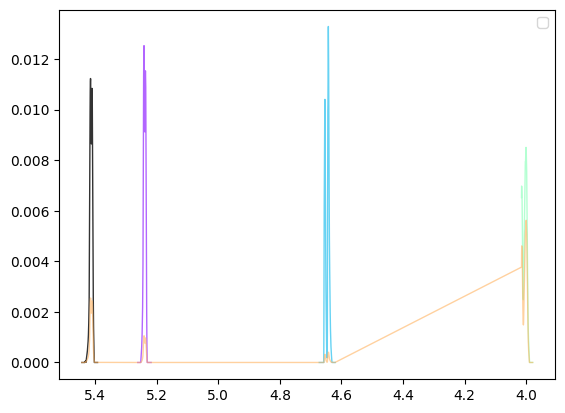

In [14]:
plt.gca().invert_xaxis()
#NMRSpectrum.plot(load_spectrum(mixture_time_data, 30), profile=True)
NMRSpectrum.plot_all(reagents_spectra + [load_spectrum(mixture_time_data, 100)], profile=True)

### Asjusting settings for estiamtion and visualisation

In [15]:
color_list = saturated_colors_for_components[experiment_name]
names = substances_names[experiment_name]

if include_all:
    pass
else:
    reagents_spectra = reagents_spectra[:which_reagent_to_remove] + reagents_spectra[(which_reagent_to_remove + 1):]
    color_list = color_list[:which_reagent_to_remove] + color_list[(which_reagent_to_remove + 1):]
    names = names[:which_reagent_to_remove] + names[(which_reagent_to_remove + 1):]

### Estimation

In [16]:
kappa = 0.1
kappa_th = 1

In [17]:
proportions_in_times = []
noise_proportions_in_times = []
noise = []
noise_in_components = []

start_time = time.time()

for i in range(1, mixture_time_data.shape[1]):
    print('This is timepoint '+str(i)+'.\n')
    mix = load_spectrum(mixture_time_data, i)
    mix.trim_negative_intensities()
    mix.normalize()
    estimation = estimate_proportions(mix, reagents_spectra, what_to_compare='area', 
                                      solver=pulp.GUROBI(msg=False),
                                     MTD=kappa, MTD_th=kappa_th)
    proportions_in_times.append(estimation['proportions'])
    noise_proportions_in_times.append(estimation['proportion_of_noise_in_components'])
    noise.append(estimation['noise'])
    noise_in_components.append(estimation['noise_in_components'])
#     if i>1:
#         assert estimation['common_horizontal_axis'] == common_horizontal_axis
    common_horizontal_axis = estimation['common_horizontal_axis']
    
    print('Proportions:\n')
    print(estimation['proportions'])
    print('\n')
    print('Proportion_of_noise_in_components:\n')
    print(estimation['proportion_of_noise_in_components'])
    print('\n')

end_time = time.time()

This is timepoint 1.

Set parameter Username
Academic license - for non-commercial use only - expires 2025-12-20


/home/basia/myvirtualenv/lib/python3.12/site-packages/pulp/pulp.py:1316: UserWarning: Spaces are not permitted in the name. Converted to '_'
  warnings.warn("Spaces are not permitted in the name. Converted to '_'")


Proportions:

[0.995442442028, 0.002144191081, 0.000221310364]


Proportion_of_noise_in_components:

0.0


This is timepoint 2.

Proportions:

[0.988435220247, 0.00519581987, 0.000338528721]


Proportion_of_noise_in_components:

0.0


This is timepoint 3.

Proportions:

[0.9800719278070003, 0.007894087495000002, 0.00045510424200000013]


Proportion_of_noise_in_components:

0.0


This is timepoint 4.

Proportions:

[0.9718168485040002, 0.010090944358000002, 0.0006585285810000001]


Proportion_of_noise_in_components:

0.0


This is timepoint 5.

Proportions:

[0.961906070488, 0.0121506459, 0.000902039944]


Proportion_of_noise_in_components:

0.0


This is timepoint 6.

Proportions:

[0.9532890479100002, 0.013720229869000003, 0.0012260874500000002]


Proportion_of_noise_in_components:

0.0


This is timepoint 7.

Proportions:

[0.94600344418, 0.015665844342, 0.00164911618]


Proportion_of_noise_in_components:

0.0


This is timepoint 8.

Proportions:

[0.936883914685, 0.017789905734, 0.0

In [18]:
res = np.array(proportions_in_times)
_, nr_of_reagents = res.shape

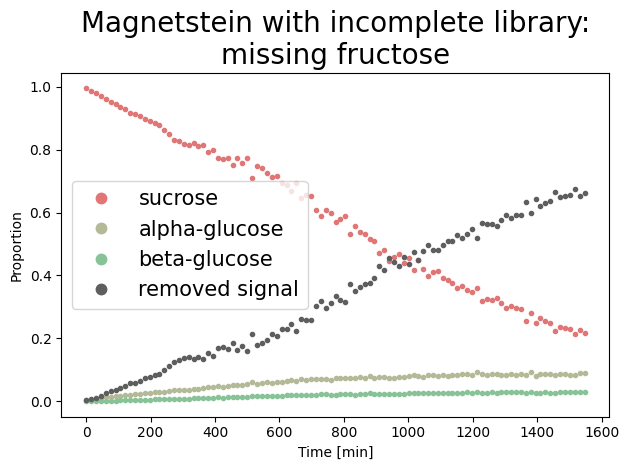

In [19]:
if experiment_name == 'Saccharose hydrolysis':
    for reag_nr in range(nr_of_reagents):
        plt.plot(time_range[experiment_name], res[:,reag_nr], '.', color=color_list[reag_nr],
                label = names[reag_nr])
if include_all:
    plt.title('Magnetstein with complete library \n', size=20)
else:
    plt.title('\n'.join(wrap('Magnetstein with incomplete library: missing ' + substances_names[experiment_name][which_reagent_to_remove],
                            40)
                       ),
              size=20)
    plt.plot(time_range[experiment_name], 1-res.sum(axis=1), '.', color='#5e5e5e', label='removed signal')
    
plt.xlabel('Time [min]')
plt.ylabel('Proportion')
leg = plt.legend(fontsize=15)
for handle in leg.legend_handles:
    handle.set_markersize(15)

plt.tight_layout()

if include_all:
    plt.savefig(results_paths[experiment_name]+'all_components_kappa_'+str(kappa)+'_'+str(kappa_th)+'.png')
else:
    plt.savefig(results_paths[experiment_name]+'removed_component_'+str(which_reagent_to_remove)+'_kappa_'+str(kappa)+'_'+str(kappa_th)+'.png')